# STEP 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, ConfusionMatrixDisplay


# STEP 2: Load the Dataset

In [2]:
df = pd.read_csv("Crop Yiled with Soil and Weather.csv")
df.head()

,Fertilizer,temp,N,P,K,yeild
0,80.0,28.0,80.0,24.0,20.0,12.0
1,77.0,27.0,78.0,23.0,20.0,12.0
2,80.0,26.0,80.0,24.0,20.0,12.0
3,80.0,28.0,80.0,24.0,20.0,12.0
4,78.0,27.0,78.0,23.0,19.0,12.0


# STEP 3: Data Summary

In [3]:
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())


Dataset Shape: (2596, 6)

Data Types:
 Fertilizer    float64
temp          float64
N             float64
P             float64
K             float64
yeild         float64
dtype: object

Missing Values:
 Fertilizer    0
temp          0
N             0
P             0
K             0
yeild         0
dtype: int64

Summary Statistics:
         Fertilizer         temp            N            P            K  \
count  2596.000000  2596.000000  2596.000000  2596.000000  2596.000000   
mean     66.487433    33.848237    69.522900    20.708194    17.806268   
std       9.747669     5.371279     6.802806     1.973419     1.940037   
min      49.751436    23.771310    58.839466    17.723223    14.704883   
25%      59.865423    28.000000    64.834635    18.988224    15.975932   
50%      65.011969    36.965121    69.894076    20.889579    18.061975   
75%      76.943112    38.928914    76.845919    22.125618    19.133858   
max      80.223893    40.272480    80.218705    25.162178    22.064666   


#  STEP 4: Data Visualization

## Correlation heatmap

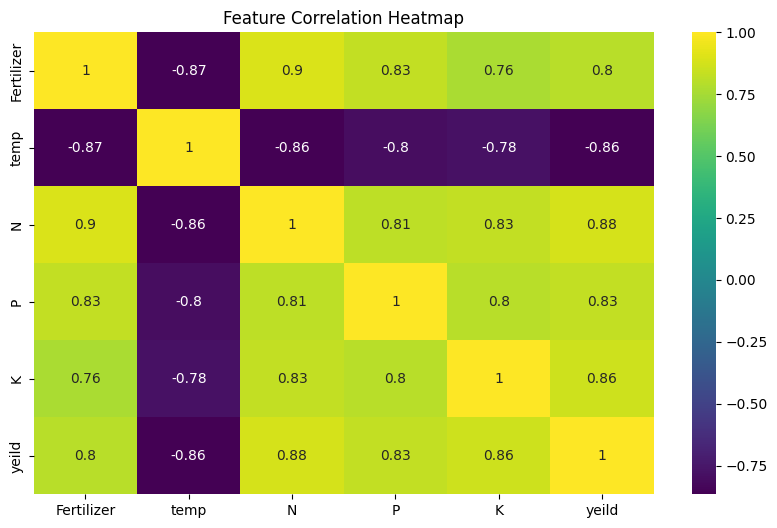

In [4]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='viridis')
plt.title("Feature Correlation Heatmap")
plt.show()

## Distribution plots

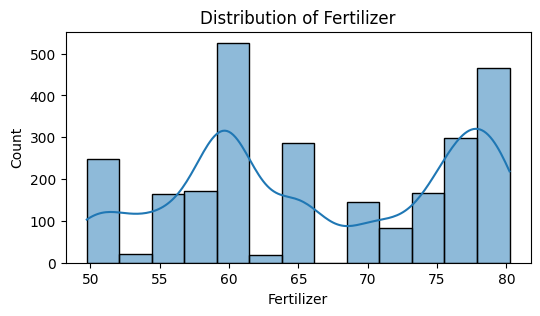

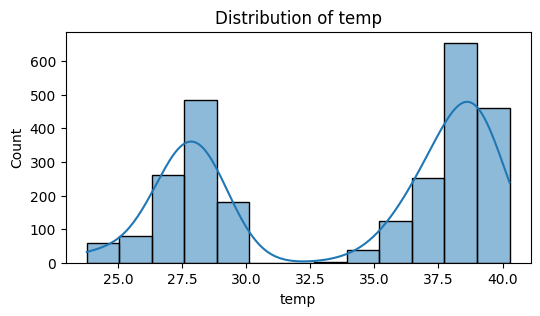

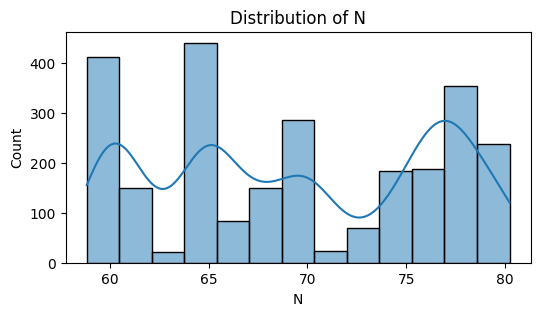

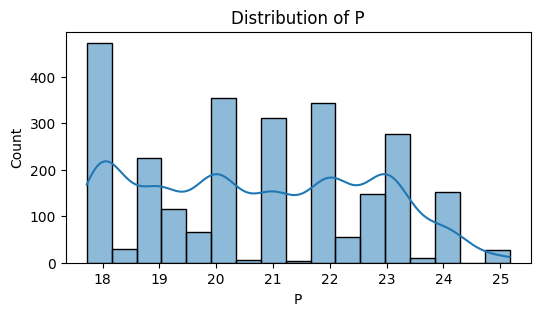

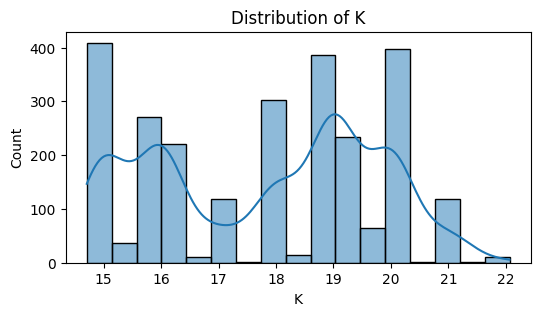

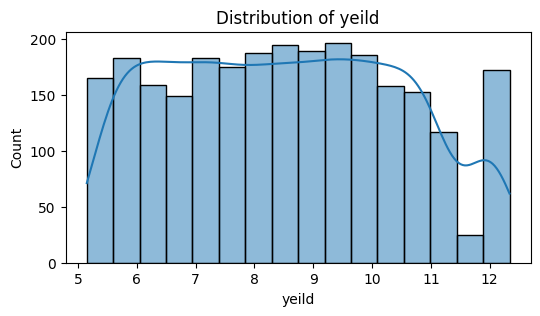

In [5]:
for column in df.columns:
    plt.figure(figsize=(6,3))
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

## Pairplot to explore pairwise relationships

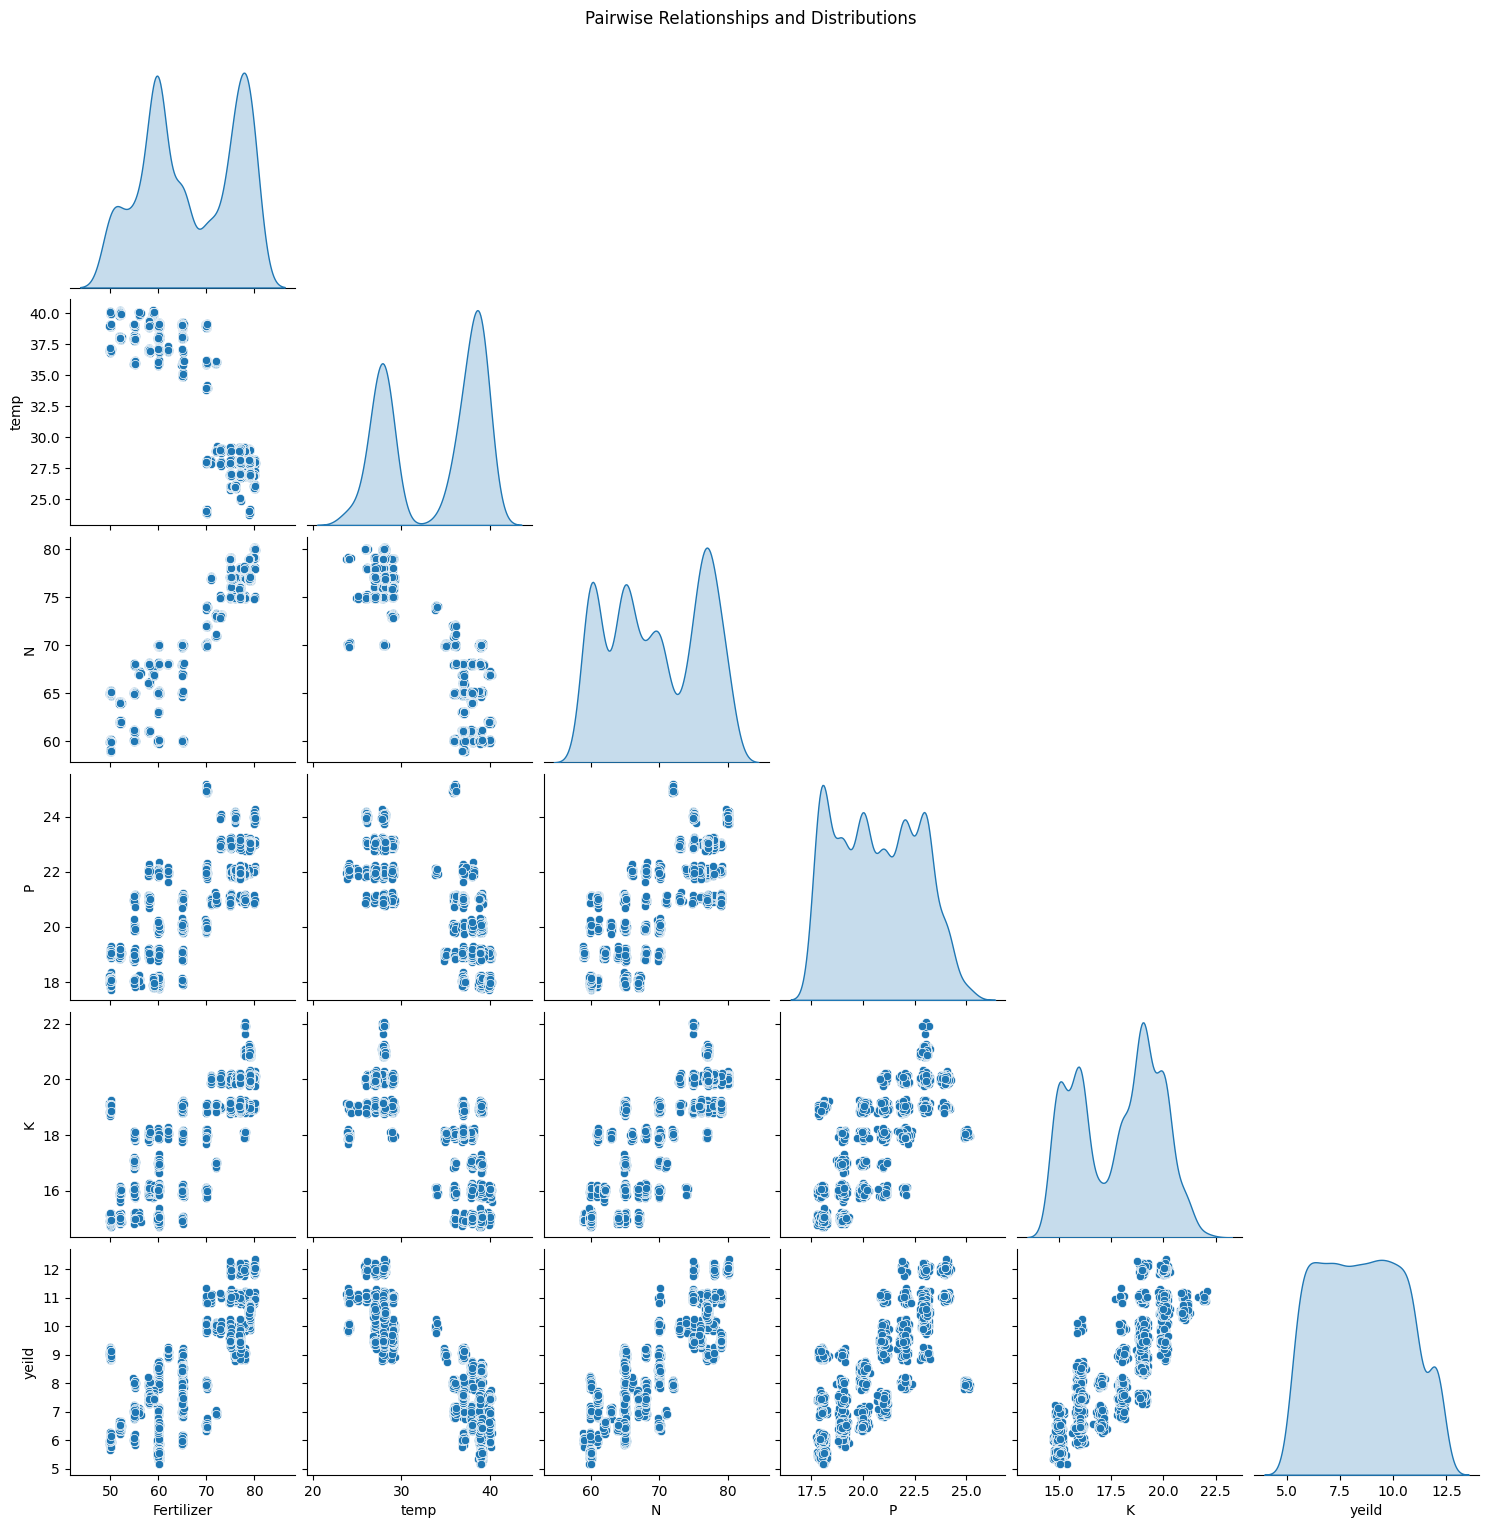

In [6]:
sns.pairplot(df, diag_kind='kde', corner=True)
plt.suptitle("Pairwise Relationships and Distributions", y=1.02)
plt.show()

## Plot boxplots for each feature

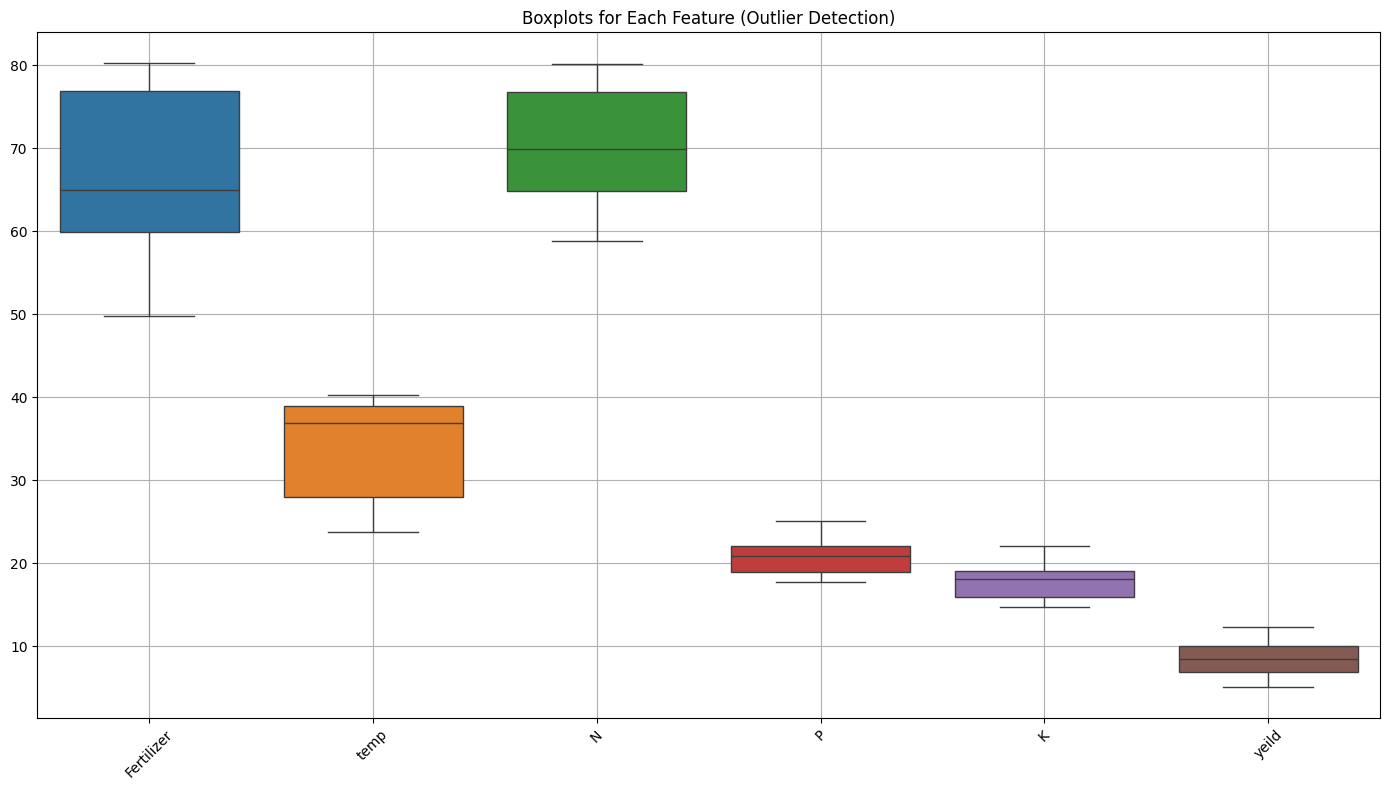

In [7]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df)
plt.title("Boxplots for Each Feature (Outlier Detection)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5: Feature Selection and Splitting

In [8]:
X = df.drop(columns=['yeild'])
y = df['yeild']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled, columns=X.columns)

from scipy import stats
z_scores = np.abs(stats.zscore(X))
X = X[(z_scores < 3).all(axis=1)]
y = y[X.index]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 6: Model Training

## Random Forest

In [10]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## XGBoost

In [11]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

## Linear Regression

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

## Support Vector Regressor

In [13]:
from sklearn.svm import SVR
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

# STEP 7: Model Evaluation

--- Random Forest ---
R2 Score:  0.9907571931953526
RMSE:  0.18637850935561853
MAE:  0.12288076767219316


--- XGBoost ---
R2 Score:  0.9882873640361505
RMSE:  0.20980760146929342
MAE:  0.13734706028581023


--- Linear Regression ---
R2 Score:  0.8626481116038349
RMSE:  0.718474259778752
MAE:  0.5790959180338147


--- SVR ---
R2 Score:  0.9366739690089325
RMSE:  0.4878485638277281
MAE:  0.3267862029550338




/tmp/ipython-input-14-465832992.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=results_df, ax=axs[0], palette="crest")
/tmp/ipython-input-14-465832992.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=results_df, ax=axs[1], palette="flare")
/tmp/ipython-input-14-465832992.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=results_df, ax=axs[2], palette="mako")


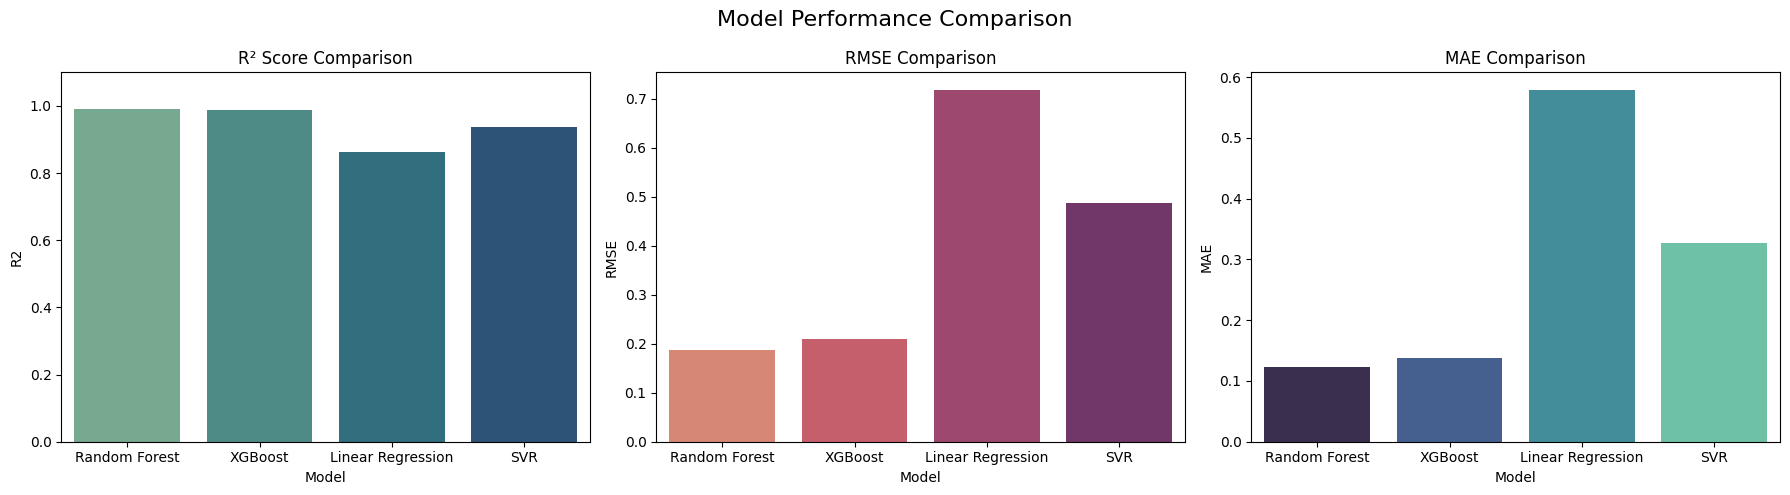

In [14]:
def evaluate_model(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"--- {name} ---")
    print("R2 Score: ", r2)
    print("RMSE: ", rmse)
    print("MAE: ", mae)
    print("\n")

    return {'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae}

results = []
results.append(evaluate_model(y_test, y_pred_rf, "Random Forest"))
results.append(evaluate_model(y_test, y_pred_xgb, "XGBoost"))
results.append(evaluate_model(y_test, y_pred_lr, "Linear Regression"))
results.append(evaluate_model(y_test, y_pred_svr, "SVR"))

results_df = pd.DataFrame(results)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='Model', y='R2', data=results_df, ax=axs[0], palette="crest")
axs[0].set_title("R² Score Comparison")
axs[0].set_ylim(0, 1.1)

sns.barplot(x='Model', y='RMSE', data=results_df, ax=axs[1], palette="flare")
axs[1].set_title("RMSE Comparison")

sns.barplot(x='Model', y='MAE', data=results_df, ax=axs[2], palette="mako")
axs[2].set_title("MAE Comparison")

plt.suptitle("Model Performance Comparison", fontsize=16)
plt.tight_layout()
plt.show()


# STEP 8: Feature Importance (Random Forest)

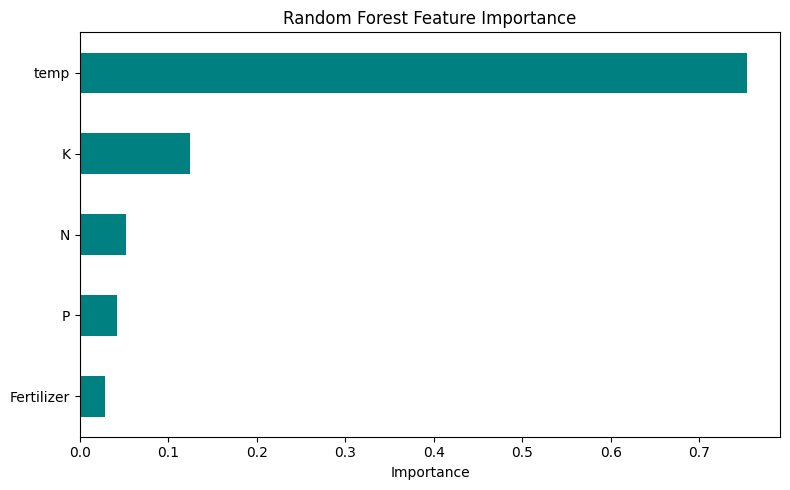

In [15]:
importances = rf.feature_importances_
feature_names = X.columns
forest_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(8, 5))
forest_importances.sort_values().plot(kind='barh', color='teal')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## SHAP

ExactExplainer explainer: 2597it [02:31, 16.29it/s]


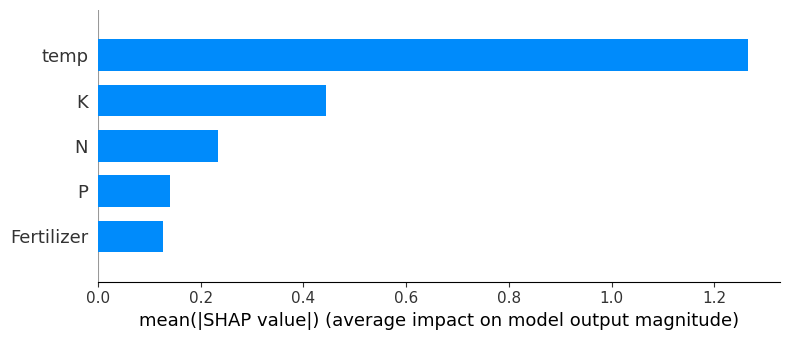

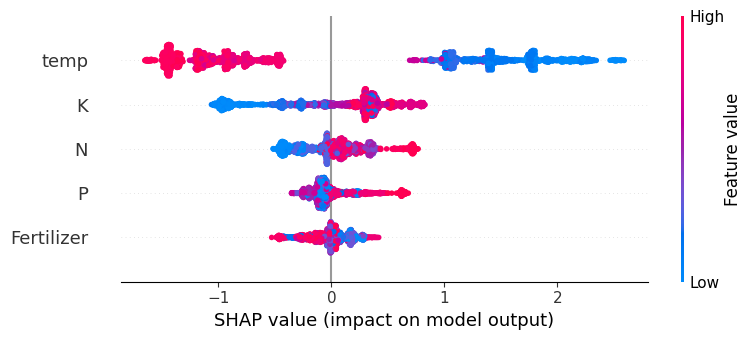

In [16]:
import shap

explainer = shap.Explainer(rf.predict, X)
shap_values = explainer(X)

shap.summary_plot(shap_values, X, plot_type="bar")

shap.summary_plot(shap_values, X)


# Step 9: Create a DataFrame to compare actual vs predicted yields

In [17]:
results_df = pd.DataFrame()
results_df['Actual_Yield'] = y_test.reset_index(drop=True)

results_df['RandomForest_Pred'] = pd.Series(y_pred_rf)
results_df['XGBoost_Pred'] = pd.Series(y_pred_xgb)
results_df['LinearReg_Pred'] = pd.Series(y_pred_lr)
results_df['SVR_Pred'] = pd.Series(y_pred_svr)

results_df.head(10)


,Actual_Yield,RandomForest_Pred,XGBoost_Pred,LinearReg_Pred,SVR_Pred
0,8.055495,7.996779,7.986559,7.894378,7.953195
1,8.466227,8.472768,8.472713,8.185867,8.390456
2,6.485449,6.499434,6.501211,6.750919,6.463720
3,10.193381,10.512146,10.476593,10.647906,10.520820
4,6.398799,6.545920,6.501948,7.050085,6.973876
5,9.059307,9.044666,9.044150,8.174014,9.138983
6,6.983481,7.338599,7.302256,7.459885,7.104692
7,10.739964,10.596607,10.624446,10.826791,10.533816
8,8.997036,8.895371,8.919852,8.220819,8.850872
9,5.942245,5.959449,5.937597,6.279922,6.310479


## Actual vs Predicted Plot for 4 Models

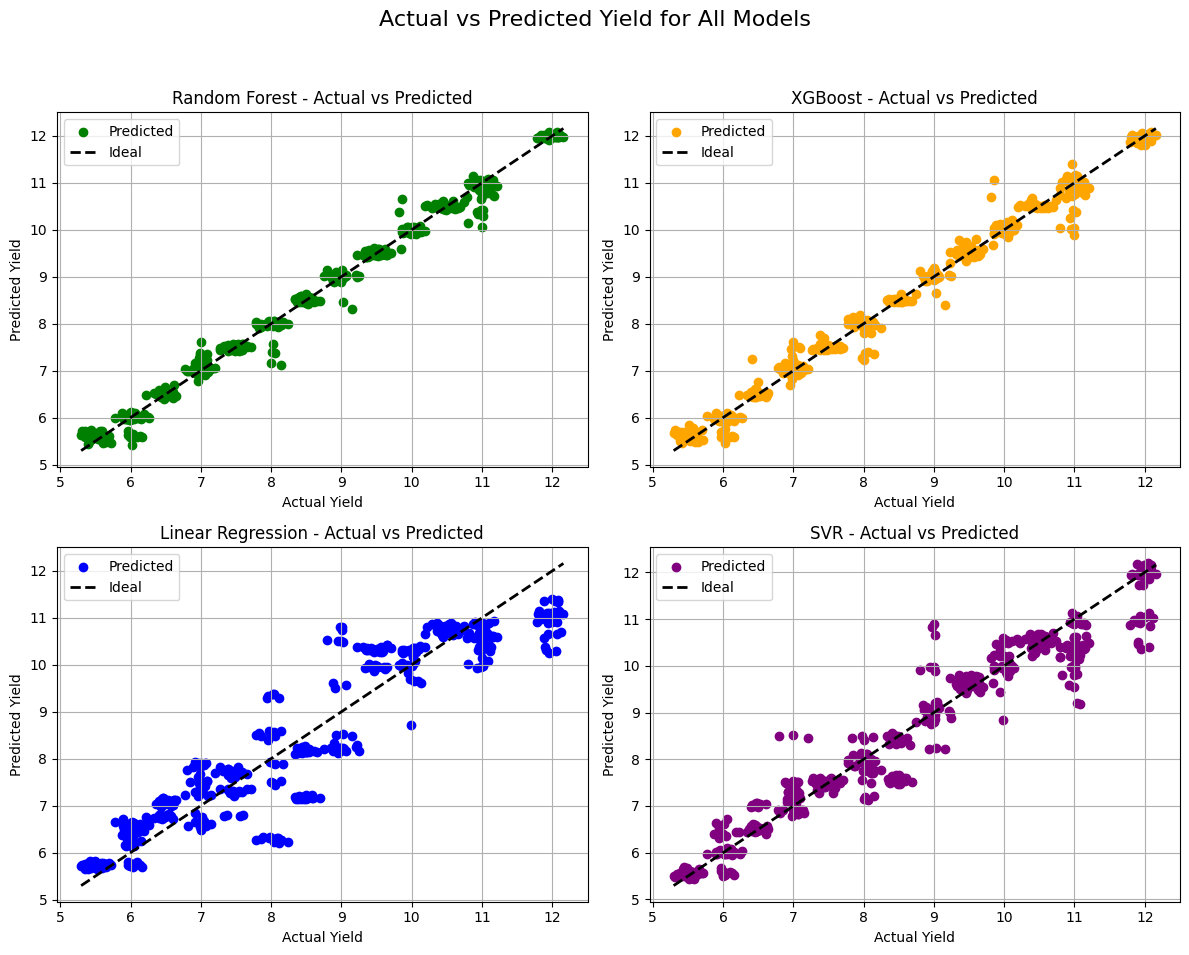

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# 1. Random Forest
axs[0, 0].scatter(y_test, y_pred_rf, color='green', label='Predicted')
axs[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal')
axs[0, 0].set_title("Random Forest - Actual vs Predicted")
axs[0, 0].set_xlabel("Actual Yield")
axs[0, 0].set_ylabel("Predicted Yield")
axs[0, 0].legend()
axs[0, 0].grid(True)

# 2. XGBoost
axs[0, 1].scatter(y_test, y_pred_xgb, color='orange', label='Predicted')
axs[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal')
axs[0, 1].set_title("XGBoost - Actual vs Predicted")
axs[0, 1].set_xlabel("Actual Yield")
axs[0, 1].set_ylabel("Predicted Yield")
axs[0, 1].legend()
axs[0, 1].grid(True)

# 3. Linear Regression
axs[1, 0].scatter(y_test, y_pred_lr, color='blue', label='Predicted')
axs[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal')
axs[1, 0].set_title("Linear Regression - Actual vs Predicted")
axs[1, 0].set_xlabel("Actual Yield")
axs[1, 0].set_ylabel("Predicted Yield")
axs[1, 0].legend()
axs[1, 0].grid(True)

# 4. SVR
axs[1, 1].scatter(y_test, y_pred_svr, color='purple', label='Predicted')
axs[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal')
axs[1, 1].set_title("SVR - Actual vs Predicted")
axs[1, 1].set_xlabel("Actual Yield")
axs[1, 1].set_ylabel("Predicted Yield")
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.suptitle("Actual vs Predicted Yield for All Models", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
